Day 1 - Data Loading cleaning and basic EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("claim_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Claim ID            1000 non-null   object
 1   Provider ID         1000 non-null   int64 
 2   Patient ID          1000 non-null   int64 
 3   Date of Service     1000 non-null   object
 4   Billed Amount       1000 non-null   int64 
 5   Procedure Code      1000 non-null   int64 
 6   Diagnosis Code      1000 non-null   object
 7   Allowed Amount      1000 non-null   int64 
 8   Paid Amount         1000 non-null   int64 
 9   Insurance Type      1000 non-null   object
 10  Claim Status        1000 non-null   object
 11  Reason Code         1000 non-null   object
 12  Follow-up Required  1000 non-null   object
 13  AR Status           1000 non-null   object
 14  Outcome             1000 non-null   object
dtypes: int64(6), object(9)
memory usage: 117.3+ KB


In [2]:
df.head()

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome
0,0HO1FSN4AP,126528997,7936697103,08/07/2024,304,99231,A02.1,218,203,Self-Pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid
1,9U86CI2P5A,6986719948,1547160031,06/21/2024,348,99213,A16.5,216,206,Medicare,Paid,Pre-existing condition,Yes,Open,Denied
2,1QEU1AIDAU,1355108115,2611585318,07/04/2024,235,99213,A00.1,148,119,Commercial,Under Review,Duplicate claim,No,Denied,Denied
3,WH7XDS8CEO,9991055906,7167948632,05/26/2024,112,99215,A18.6,79,69,Medicare,Denied,Authorization not obtained,No,Partially Paid,Denied
4,M6OJEZ8KGI,7382167012,2140226267,07/16/2024,406,99238,A17.9,320,259,Medicare,Denied,Authorization not obtained,No,On Hold,Denied


In [3]:
df['Date of Service'] = pd.to_datetime(df['Date of Service'])
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.isnull().sum())

0
Claim ID              0
Provider ID           0
Patient ID            0
Date of Service       0
Billed Amount         0
Procedure Code        0
Diagnosis Code        0
Allowed Amount        0
Paid Amount           0
Insurance Type        0
Claim Status          0
Reason Code           0
Follow-up Required    0
AR Status             0
Outcome               0
dtype: int64


In [4]:
df[['Billed Amount', 'Allowed Amount', 'Paid Amount']].describe()

,Billed Amount,Allowed Amount,Paid Amount
count,1000.00000,1000.000000,1000.000000
mean,297.19100,223.112000,200.754000
std,116.36365,90.784731,83.353688
min,100.00000,64.000000,53.000000
25%,197.00000,147.750000,133.000000
50%,297.00000,225.000000,200.000000
75%,395.00000,289.000000,262.000000
max,500.00000,442.000000,423.000000


In [5]:
cols = ['Billed Amount', 'Allowed Amount', 'Paid Amount']
print("Mean:")
print(df[cols].mean())
print("\nMedian:")
print(df[cols].median())

Mean:
Billed Amount     297.191
Allowed Amount    223.112
Paid Amount       200.754
dtype: float64

Median:
Billed Amount     297.0
Allowed Amount    225.0
Paid Amount       200.0
dtype: float64


In [6]:
denial_reasons = df["Reason Code"].value_counts()
print(denial_reasons)

Reason Code
Authorization not obtained       154
Incorrect billing information    142
Missing documentation            126
Patient eligibility issues       126
Pre-existing condition           121
Duplicate claim                  113
Service not covered              111
Lack of medical necessity        107
Name: count, dtype: int64


Revenue Leakage

In [7]:
average_billed = df['Billed Amount'].mean()
average_paid = df['Paid Amount'].mean()
x = (average_paid / average_billed) * 100
print(f"Average Billed Amount: ${average_billed:.2f}")
print(f"Average Paid Amount: ${average_paid:.2f}")
print(f"Average Paid Amount as a percentage of Average Billed Amount: {x:.2f}%")

Average Billed Amount: $297.19
Average Paid Amount: $200.75
Average Paid Amount as a percentage of Average Billed Amount: 67.55%


Denial Rate

In [8]:
denial_rate = (df['Claim Status'] == 'Denied').mean() * 100
print(f"Denial Rate: {denial_rate:.2f}%")
pending_rate = (df['Claim Status'] == 'Pending').mean() * 100
print(f"Pending Rate: {pending_rate:.2f}%")
print(f"Total not immediately paid: {denial_rate + pending_rate:.1f}%")

Denial Rate: 32.80%
Pending Rate: 0.00%
Total not immediately paid: 32.8%


Outcome Loss


In [9]:
not_fully_paid = df[df['Outcome']!= 'Paid'].shape[0]
total = len(df)
print(f"Total Claims     : {total}")
print(f"Not Fully Paid   : {not_fully_paid}({(not_fully_paid / total)*100:.1f}%)")

Total Claims     : 1000
Not Fully Paid   : 643(64.3%)


Distribution plot

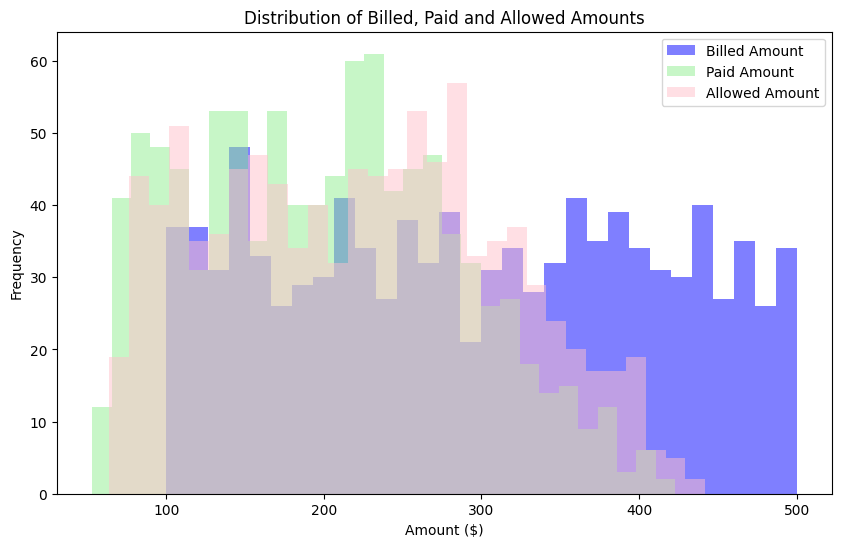

In [10]:
plt.figure(figsize=(10,6))
plt.hist(df['Billed Amount'], bins=30, alpha=0.5, label='Billed Amount', color='blue')
plt.hist(df['Paid Amount'], bins=30, alpha=0.5, label='Paid Amount', color='lightgreen')
plt.hist(df['Allowed Amount'], bins=30, alpha=0.5, label='Allowed Amount', color='pink')
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Billed, Paid and Allowed Amounts')
plt.legend()
plt.show()

DAY 2 - Visual & Insights

Claim Outcome Distribution

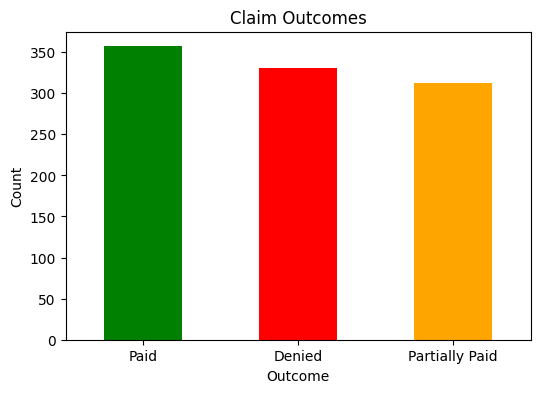

In [11]:
df['Outcome'].value_counts().plot(kind='bar', figsize=(6,4), color=['green','red','orange'])
plt.title('Claim Outcomes')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Top Denial Reasons

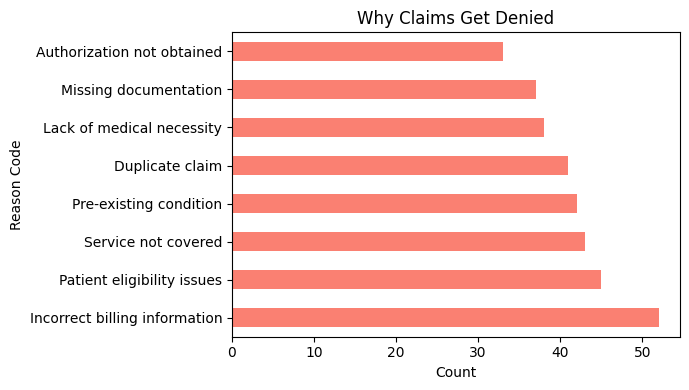

In [12]:
df[df['Outcome'] == 'Denied']['Reason Code'].value_counts().plot(kind='barh', figsize=(7,4), color='salmon')
plt.title('Why Claims Get Denied')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

Billed vs Paid Amount

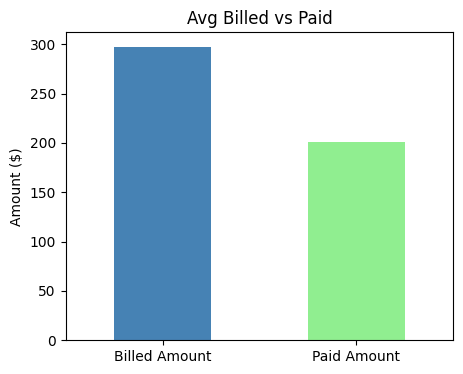

In [13]:
df[['Billed Amount', 'Paid Amount']].mean().plot(kind='bar', figsize=(5,4), color=['steelblue','lightgreen'])
plt.title('Avg Billed vs Paid')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.show()

Day 3 - Final Cleaning and Exportation of Data

Final Cleaning

In [14]:
df['Date of Service'] = pd.to_datetime(df['Date of Service'])
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
print("Final shape:", df.shape)
print(df.dtypes)

Final shape: (1000, 15)
Claim ID                      object
Provider ID                    int64
Patient ID                     int64
Date of Service       datetime64[ns]
Billed Amount                  int64
Procedure Code                 int64
Diagnosis Code                object
Allowed Amount                 int64
Paid Amount                    int64
Insurance Type                object
Claim Status                  object
Reason Code                   object
Follow-up Required            object
AR Status                     object
Outcome                       object
dtype: object


In [16]:
df['Claim Gap'] = df['Billed Amount'] - df['Paid Amount']
df['Recovery Rate'] = (df['Paid Amount'] / df['Billed Amount'] * 100).round(2)
print("Adding 'Claim Gap' and 'Recovery Rate' columns:")
df.head()

Adding 'Claim Gap' and 'Recovery Rate' columns:


,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome,Claim Gap,Recovery Rate
0,0HO1FSN4AP,126528997,7936697103,2024-08-07,304,99231,A02.1,218,203,Self-Pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid,101,66.78
1,9U86CI2P5A,6986719948,1547160031,2024-06-21,348,99213,A16.5,216,206,Medicare,Paid,Pre-existing condition,Yes,Open,Denied,142,59.20
2,1QEU1AIDAU,1355108115,2611585318,2024-07-04,235,99213,A00.1,148,119,Commercial,Under Review,Duplicate claim,No,Denied,Denied,116,50.64
3,WH7XDS8CEO,9991055906,7167948632,2024-05-26,112,99215,A18.6,79,69,Medicare,Denied,Authorization not obtained,No,Partially Paid,Denied,43,61.61
4,M6OJEZ8KGI,7382167012,2140226267,2024-07-16,406,99238,A17.9,320,259,Medicare,Denied,Authorization not obtained,No,On Hold,Denied,147,63.79


In [17]:
df.to_csv('clean_claim_data.csv', index=False)
print("File saved!")

File saved!
